In [109]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == "Darwin":   # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:                               # Windows / Linux
    plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False

In [110]:
df = pd.read_csv("../Data/testset/서울시설공단_공영주차장 시간별 주차현황_20250531.csv", encoding="euc-kr")

In [111]:
sp = df[df["주차장명"] == "영등포구청역"]

In [112]:
sp["시간대"] = pd.to_datetime(sp["시간대"])

sp["year"] = sp["시간대"].dt.year
sp["month"] = sp["시간대"].dt.month
sp["day"] = sp["시간대"].dt.day
sp["hour"] = sp["시간대"].dt.hour

In [113]:
del sp["시간대"]

In [114]:
sp1 = sp.reset_index(drop=True)

In [115]:
sp1

,주차장명,주차면수,입차대수,출차대수,year,month,day,hour
0,영등포구청역,137,0,2,2022,5,1,0
1,영등포구청역,137,3,2,2022,5,1,1
2,영등포구청역,137,0,1,2022,5,1,2
3,영등포구청역,137,0,0,2022,5,1,3
4,영등포구청역,137,0,0,2022,5,1,4
...,...,...,...,...,...,...,...,...
26875,영등포구청역,137,2,3,2025,5,31,19
26876,영등포구청역,137,2,4,2025,5,31,20
26877,영등포구청역,137,3,4,2025,5,31,21
26878,영등포구청역,137,1,1,2025,5,31,22


In [116]:
sp2 = sp1[sp1["year"] == 2025]

In [117]:
sp2 = sp2.sort_values(["year", "month", "day", "hour"]).reset_index(drop=True)

df_preset = sp2.copy()
df_preset["date"] = pd.to_datetime(df_preset[["year", "month", "day"]])

capacity = df_preset["주차면수"].iloc[0]
net_change = df_preset["출차대수"] - df_preset["입차대수"]
df_preset["available"] = (
    capacity + net_change.groupby(df_preset["date"]).cumsum()
).clip(lower=0, upper=capacity)

df_preset

,주차장명,주차면수,입차대수,출차대수,year,month,day,hour,date,available
0,영등포구청역,137,1,2,2025,1,1,0,2025-01-01,137
1,영등포구청역,137,0,1,2025,1,1,1,2025-01-01,137
2,영등포구청역,137,0,0,2025,1,1,2,2025-01-01,137
3,영등포구청역,137,0,0,2025,1,1,3,2025-01-01,137
4,영등포구청역,137,0,1,2025,1,1,4,2025-01-01,137
...,...,...,...,...,...,...,...,...,...,...
3619,영등포구청역,137,2,3,2025,5,31,19,2025-05-31,137
3620,영등포구청역,137,2,4,2025,5,31,20,2025-05-31,137
3621,영등포구청역,137,3,4,2025,5,31,21,2025-05-31,137
3622,영등포구청역,137,1,1,2025,5,31,22,2025-05-31,137


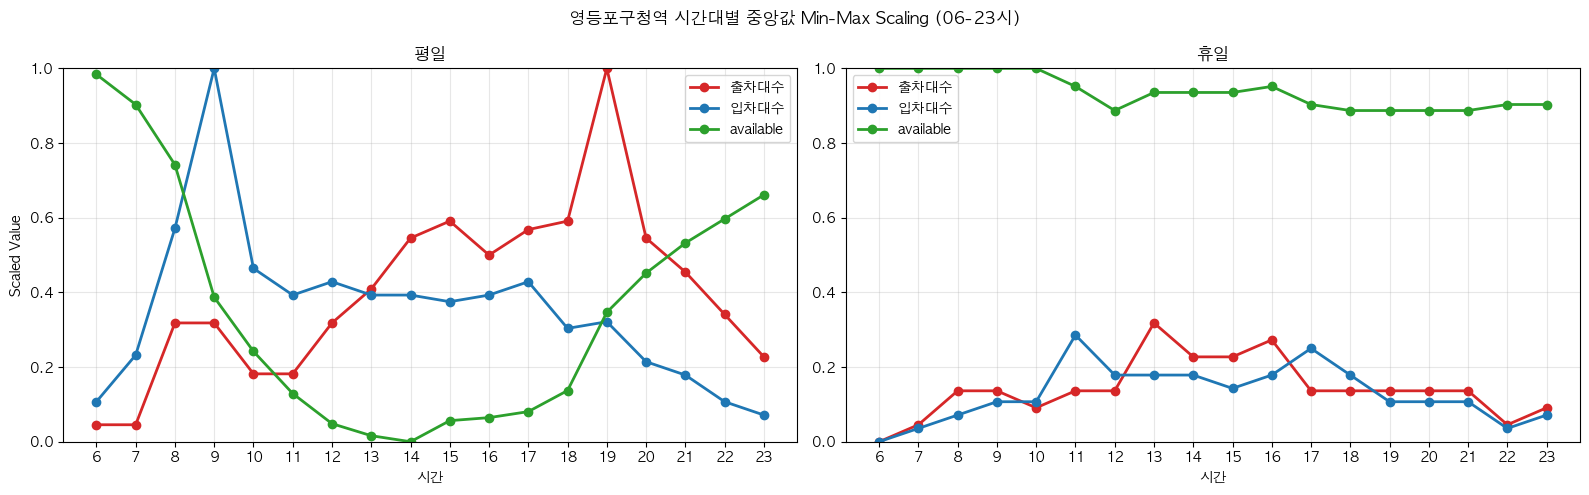

,day_type,hour,출차대수,입차대수,available
0,평일,6,0.045455,0.107143,0.983871
1,평일,7,0.045455,0.232143,0.903226
2,평일,8,0.318182,0.571429,0.741935
3,평일,9,0.318182,1.000000,0.387097
4,평일,10,0.181818,0.464286,0.241935
5,평일,11,0.181818,0.392857,0.129032
6,평일,12,0.318182,0.428571,0.048387
7,평일,13,0.409091,0.392857,0.016129
8,평일,14,0.545455,0.392857,0.000000
9,평일,15,0.590909,0.375000,0.056452


In [118]:
holiday_dates = pd.to_datetime([
    "2025-01-01",
    "2025-01-27",
    "2025-01-28",
    "2025-01-29",
    "2025-01-30",
    "2025-03-01",
    "2025-03-03",
    "2025-05-05",
    "2025-05-06",
])

df_preset["date"] = pd.to_datetime(df_preset[["year", "month", "day"]])
is_holiday = (df_preset["date"].dt.dayofweek >= 5) | (df_preset["date"].isin(holiday_dates))
df_preset["day_type"] = np.where(is_holiday, "휴일", "평일")

line_columns = ["출차대수", "입차대수", "available"]
line_colors = {
    "출차대수": "#d62728",
    "입차대수": "#1f77b4",
    "available": "#2ca02c",
}

def minmax_scale_profile(profile, columns):
    scaled_profile = profile.copy()
    for col in columns:
        col_min = scaled_profile[col].min()
        col_max = scaled_profile[col].max()
        if pd.isna(col_min) or pd.isna(col_max) or col_min == col_max:
            scaled_profile[col] = 0.0
        else:
            scaled_profile[col] = (scaled_profile[col] - col_min) / (col_max - col_min)
    return scaled_profile

hourly_profile = (
    df_preset.loc[df_preset["hour"].between(6, 23)]
    .groupby(["day_type", "hour"])[["출차대수", "입차대수", "available"]]
    .median()
    .reset_index()
)
hourly_profile_scaled = minmax_scale_profile(hourly_profile, line_columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

for ax, day_type in zip(axes, ["평일", "휴일"]):
    plot_df = hourly_profile_scaled[hourly_profile_scaled["day_type"] == day_type]
    for col in line_columns:
        ax.plot(
            plot_df["hour"],
            plot_df[col],
            marker="o",
            linewidth=2,
            color=line_colors[col],
            label=col,
        )
    ax.set_title(day_type)
    ax.set_xlabel("시간")
    ax.set_xticks(range(6, 24))
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Scaled Value")
fig.suptitle("영등포구청역 시간대별 중앙값 Min-Max Scaling (06-23시)")
plt.tight_layout()
plt.show()

hourly_profile_scaled

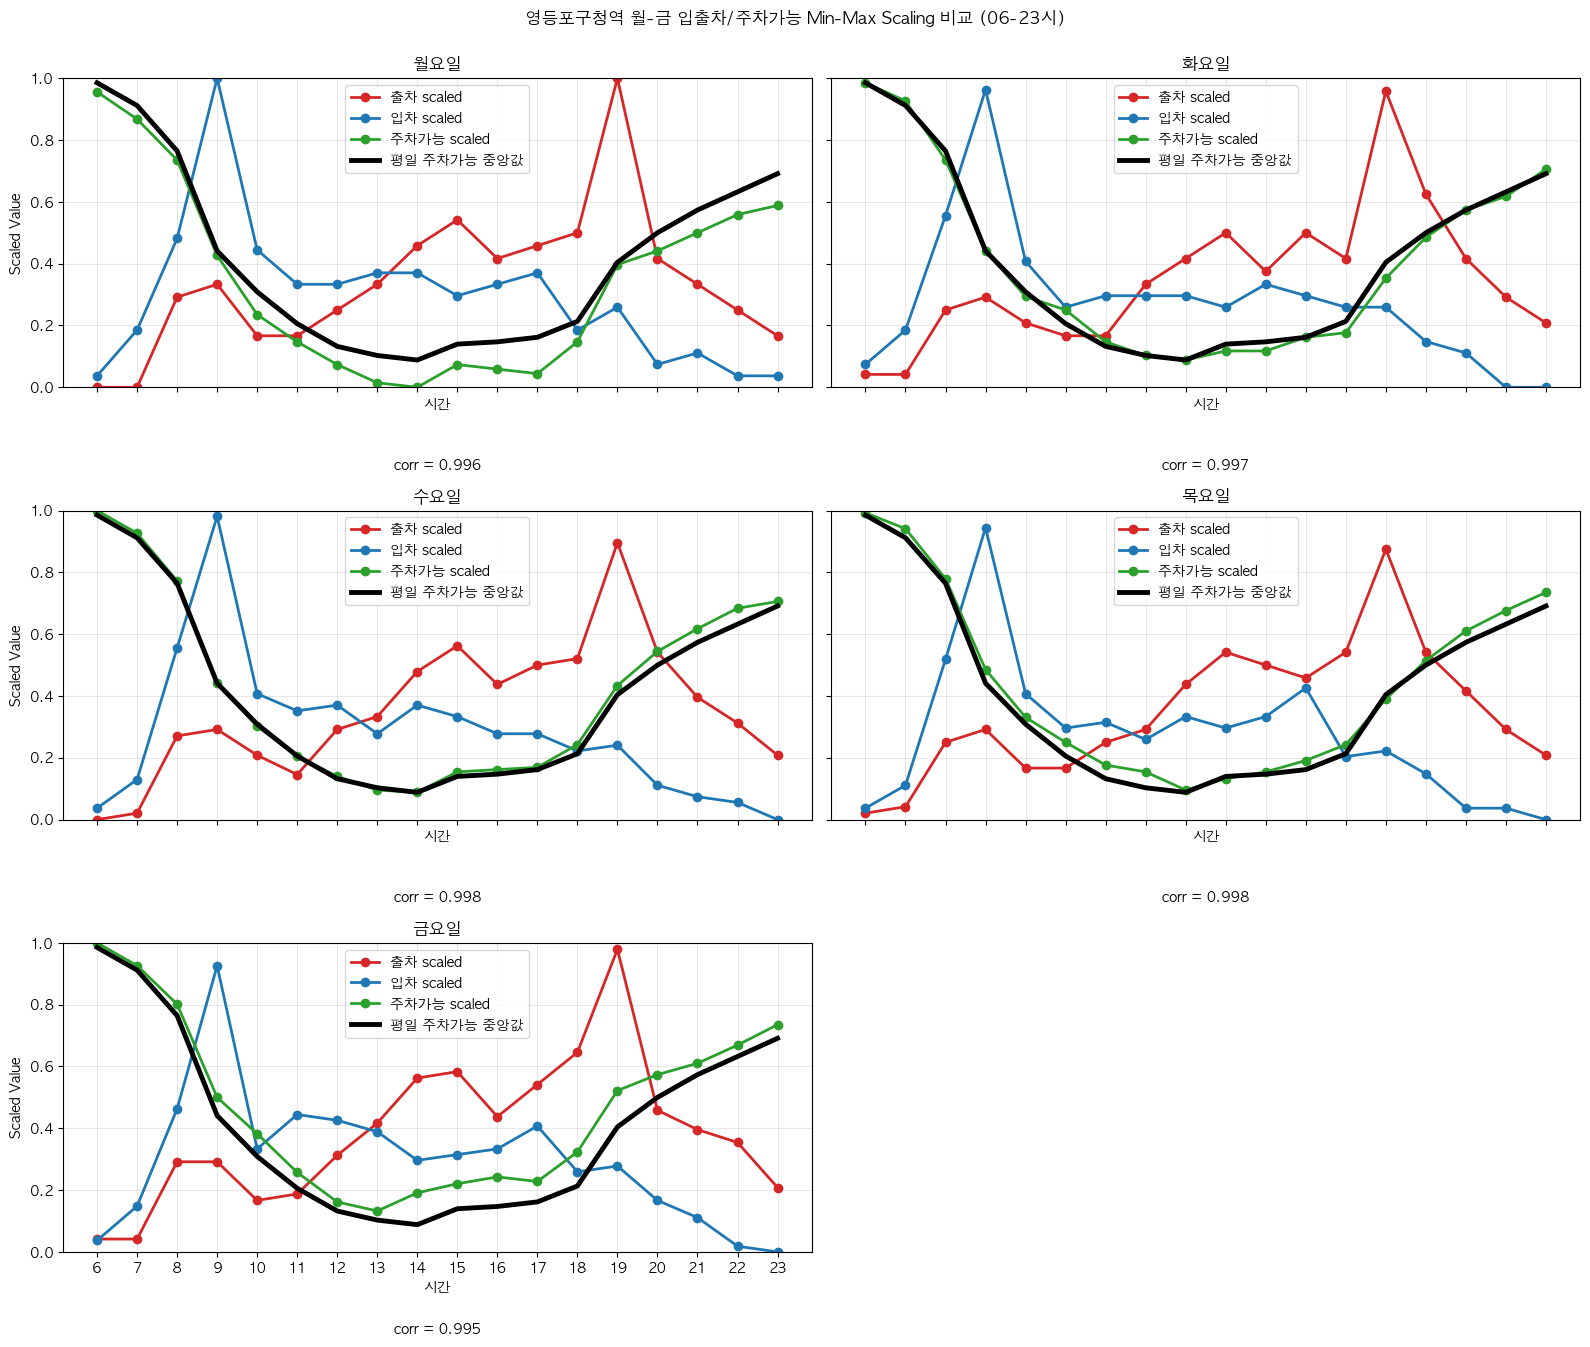

,weekday_name,corr
0,월요일,0.996164
1,화요일,0.997069
2,수요일,0.998455
3,목요일,0.997753
4,금요일,0.995326


In [119]:
weekday_map = {
    0: "월요일",
    1: "화요일",
    2: "수요일",
    3: "목요일",
    4: "금요일",
    5: "토요일",
    6: "일요일",
}
weekday_order = ["월요일", "화요일", "수요일", "목요일", "금요일"]

df_preset["weekday_name"] = pd.Categorical(
    df_preset["date"].dt.dayofweek.map(weekday_map),
    categories=list(weekday_map.values()),
    ordered=True,
)

weekday_profile = (
    df_preset.loc[df_preset["hour"].between(6, 23)]
    .groupby(["weekday_name", "hour"], observed=False)[["출차대수", "입차대수", "available"]]
    .median()
    .reset_index()
    .sort_values(["weekday_name", "hour"])
)
weekday_profile = weekday_profile[
    weekday_profile["weekday_name"].isin(weekday_order)
].copy()
weekday_profile_scaled = minmax_scale_profile(weekday_profile, line_columns)

available_min = weekday_profile["available"].min()
available_max = weekday_profile["available"].max()

weekday_baseline = (
    df_preset.loc[(df_preset["day_type"] == "평일") & df_preset["hour"].between(6, 23)]
    .groupby("hour")[["available"]]
    .median()
    .reset_index()
)

if pd.isna(available_min) or pd.isna(available_max) or available_min == available_max:
    weekday_baseline["available_scaled"] = 0.0
else:
    weekday_baseline["available_scaled"] = (
        (weekday_baseline["available"] - available_min)
        / (available_max - available_min)
    )

fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True, sharey=True)
axes = axes.flatten()

weekday_corr_rows = []

for idx, weekday_name in enumerate(weekday_order):
    ax = axes[idx]
    plot_df = weekday_profile_scaled[
        weekday_profile_scaled["weekday_name"] == weekday_name
    ][["hour", "출차대수", "입차대수", "available"]].copy()
    compare_df = plot_df.merge(
        weekday_baseline[["hour", "available_scaled"]].rename(
            columns={"available_scaled": "weekday_median_scaled"}
        ),
        on="hour",
        how="left",
    )
    corr_value = compare_df["available"].corr(compare_df["weekday_median_scaled"])
    weekday_corr_rows.append({"weekday_name": weekday_name, "corr": corr_value})

    ax.plot(
        compare_df["hour"],
        compare_df["출차대수"],
        marker="o",
        linewidth=2,
        color=line_colors["출차대수"],
        label="출차 scaled",
    )
    ax.plot(
        compare_df["hour"],
        compare_df["입차대수"],
        marker="o",
        linewidth=2,
        color=line_colors["입차대수"],
        label="입차 scaled",
    )
    ax.plot(
        compare_df["hour"],
        compare_df["available"],
        marker="o",
        linewidth=2,
        color=line_colors["available"],
        label="주차가능 scaled",
    )
    ax.plot(
        compare_df["hour"],
        compare_df["weekday_median_scaled"],
        linewidth=3.5,
        color="black",
        label="평일 주차가능 중앙값",
    )
    ax.set_title(weekday_name)
    ax.set_xlabel("시간")
    ax.set_xticks(range(6, 24))
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend()
    if idx % 2 == 0:
        ax.set_ylabel("Scaled Value")
    ax.text(
        0.5,
        -0.23,
        f"corr = {corr_value:.3f}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=10,
    )

for idx in range(len(weekday_order), len(axes)):
    axes[idx].axis("off")

fig.suptitle("영등포구청역 월-금 입출차/주차가능 Min-Max Scaling 비교 (06-23시)")
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

weekday_corr_df = pd.DataFrame(weekday_corr_rows)
weekday_corr_df

In [120]:
def plot_monthly_profile(month):
    monthly_profile = (
        df_preset.loc[(df_preset["month"] == month) & df_preset["hour"].between(6, 23)]
        .groupby(["day_type", "hour"])[["출차대수", "입차대수", "available"]]
        .median()
        .reset_index()
    )

    if monthly_profile.empty:
        print(f"{month}월 데이터가 없습니다.")
        return monthly_profile

    monthly_profile_scaled = minmax_scale_profile(monthly_profile, line_columns)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

    for ax, day_type in zip(axes, ["평일", "휴일"]):
        plot_df = monthly_profile_scaled[monthly_profile_scaled["day_type"] == day_type]
        for col in line_columns:
            ax.plot(
                plot_df["hour"],
                plot_df[col],
                marker="o",
                linewidth=2,
                color=line_colors[col],
                label=col,
            )
        ax.set_title(f"{month}월 {day_type}")
        ax.set_xlabel("시간")
        ax.set_xticks(range(6, 24))
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        ax.legend()

    axes[0].set_ylabel("Scaled Value")
    fig.suptitle(f"영등포구청역 {month}월 시간대별 중앙값 Min-Max Scaling (06-23시)")
    plt.tight_layout()
    plt.show()

    return monthly_profile_scaled

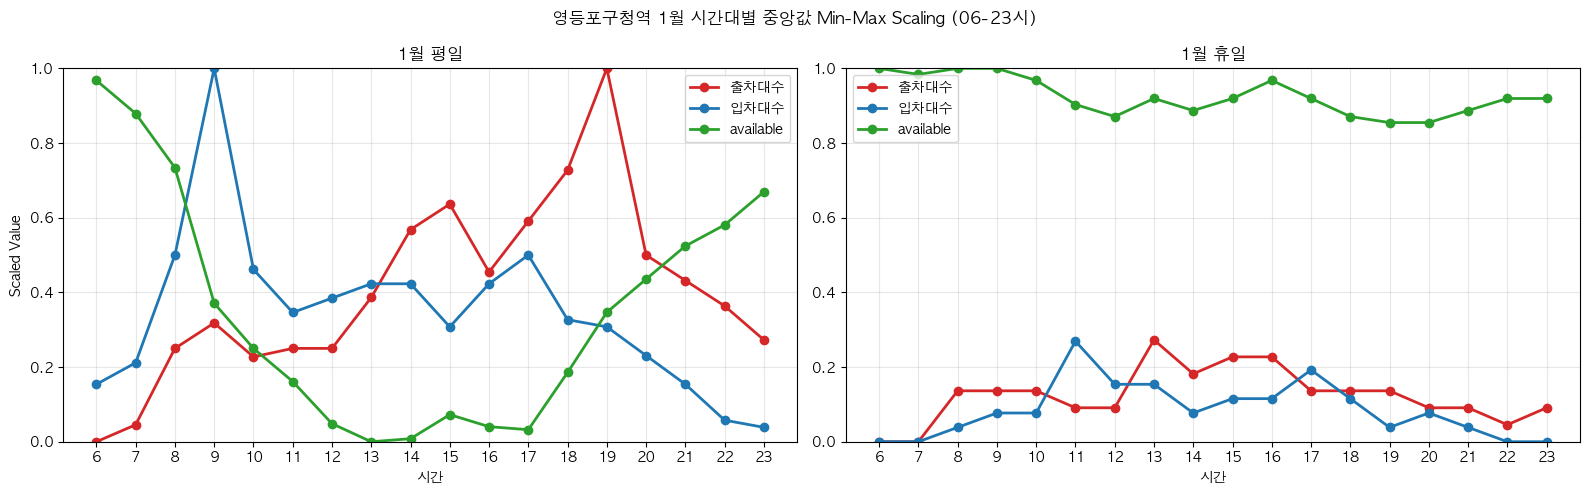

,day_type,hour,출차대수,입차대수,available
0,평일,6,0.000000,0.153846,0.967742
1,평일,7,0.045455,0.211538,0.879032
2,평일,8,0.250000,0.500000,0.733871
3,평일,9,0.318182,1.000000,0.370968
4,평일,10,0.227273,0.461538,0.250000
5,평일,11,0.250000,0.346154,0.161290
6,평일,12,0.250000,0.384615,0.048387
7,평일,13,0.386364,0.423077,0.000000
8,평일,14,0.568182,0.423077,0.008065
9,평일,15,0.636364,0.307692,0.072581


In [121]:
monthly_profile_1 = plot_monthly_profile(1)
monthly_profile_1

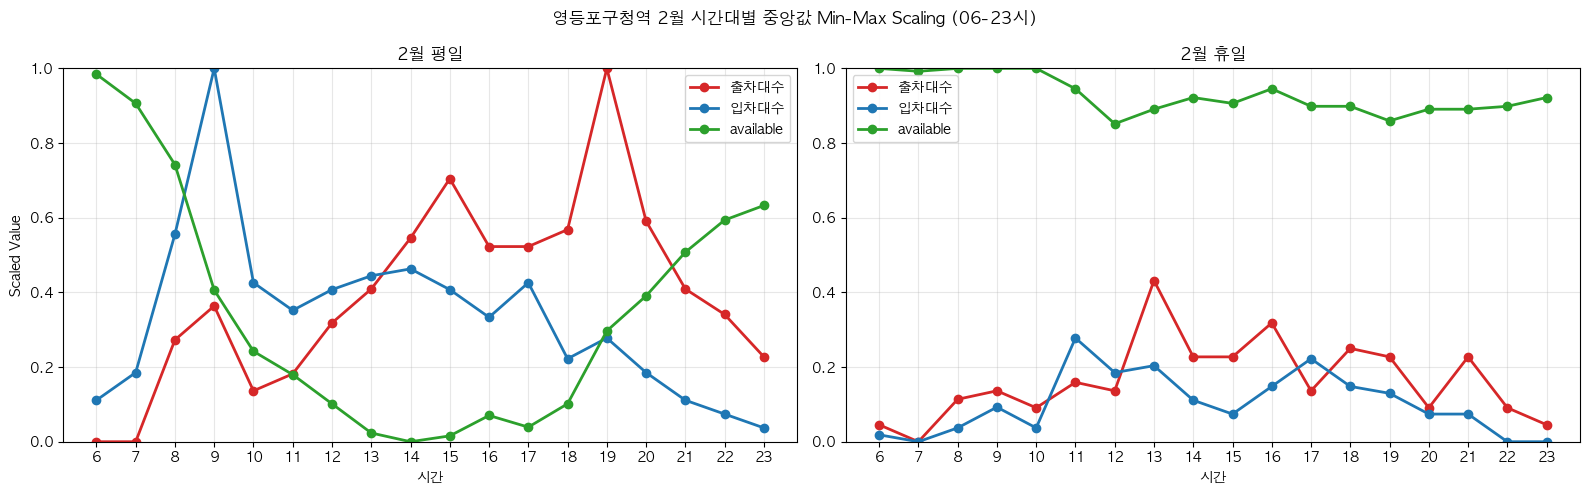

,day_type,hour,출차대수,입차대수,available
0,평일,6,0.000000,0.111111,0.984375
1,평일,7,0.000000,0.185185,0.906250
2,평일,8,0.272727,0.555556,0.742188
3,평일,9,0.363636,1.000000,0.406250
4,평일,10,0.136364,0.425926,0.242188
5,평일,11,0.181818,0.351852,0.179688
6,평일,12,0.318182,0.407407,0.101562
7,평일,13,0.409091,0.444444,0.023438
8,평일,14,0.545455,0.462963,0.000000
9,평일,15,0.704545,0.407407,0.015625


In [122]:
monthly_profile_2 = plot_monthly_profile(2)
monthly_profile_2

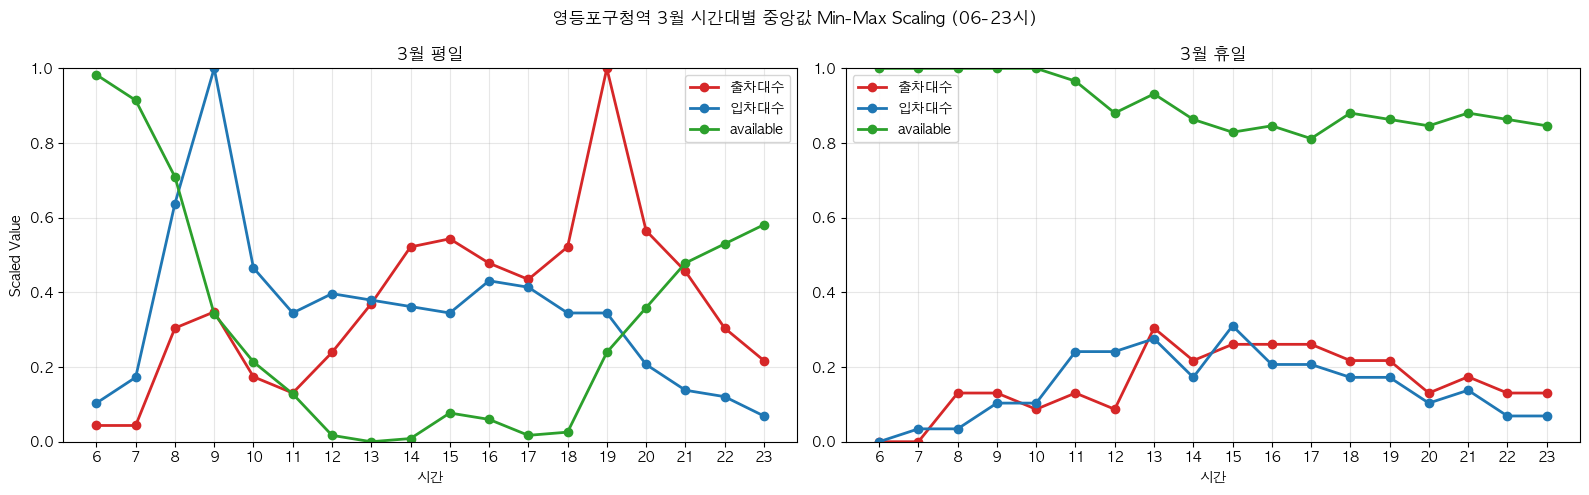

,day_type,hour,출차대수,입차대수,available
0,평일,6,0.043478,0.103448,0.982906
1,평일,7,0.043478,0.172414,0.914530
2,평일,8,0.304348,0.637931,0.709402
3,평일,9,0.347826,1.000000,0.341880
4,평일,10,0.173913,0.465517,0.213675
5,평일,11,0.130435,0.344828,0.128205
6,평일,12,0.239130,0.396552,0.017094
7,평일,13,0.369565,0.379310,0.000000
8,평일,14,0.521739,0.362069,0.008547
9,평일,15,0.543478,0.344828,0.076923


In [123]:
monthly_profile_3 = plot_monthly_profile(3)
monthly_profile_3

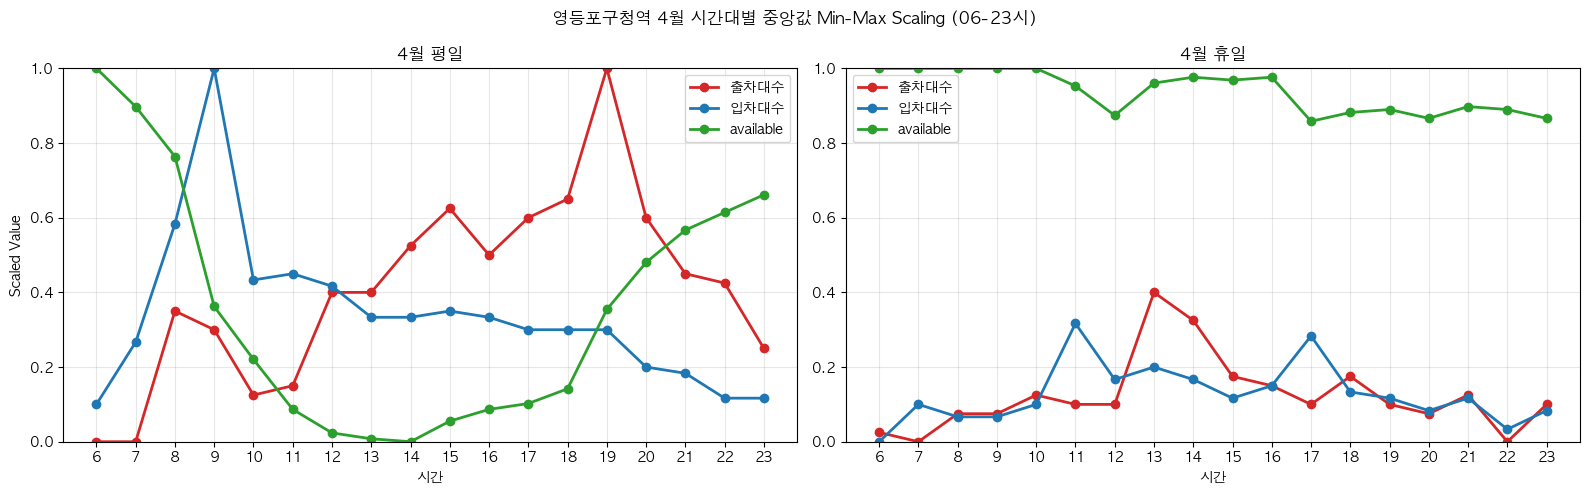

,day_type,hour,출차대수,입차대수,available
0,평일,6,0.000,0.100000,1.000000
1,평일,7,0.000,0.266667,0.897638
2,평일,8,0.350,0.583333,0.763780
3,평일,9,0.300,1.000000,0.362205
4,평일,10,0.125,0.433333,0.220472
5,평일,11,0.150,0.450000,0.086614
6,평일,12,0.400,0.416667,0.023622
7,평일,13,0.400,0.333333,0.007874
8,평일,14,0.525,0.333333,0.000000
9,평일,15,0.625,0.350000,0.055118


In [124]:
monthly_profile_4 = plot_monthly_profile(4)
monthly_profile_4

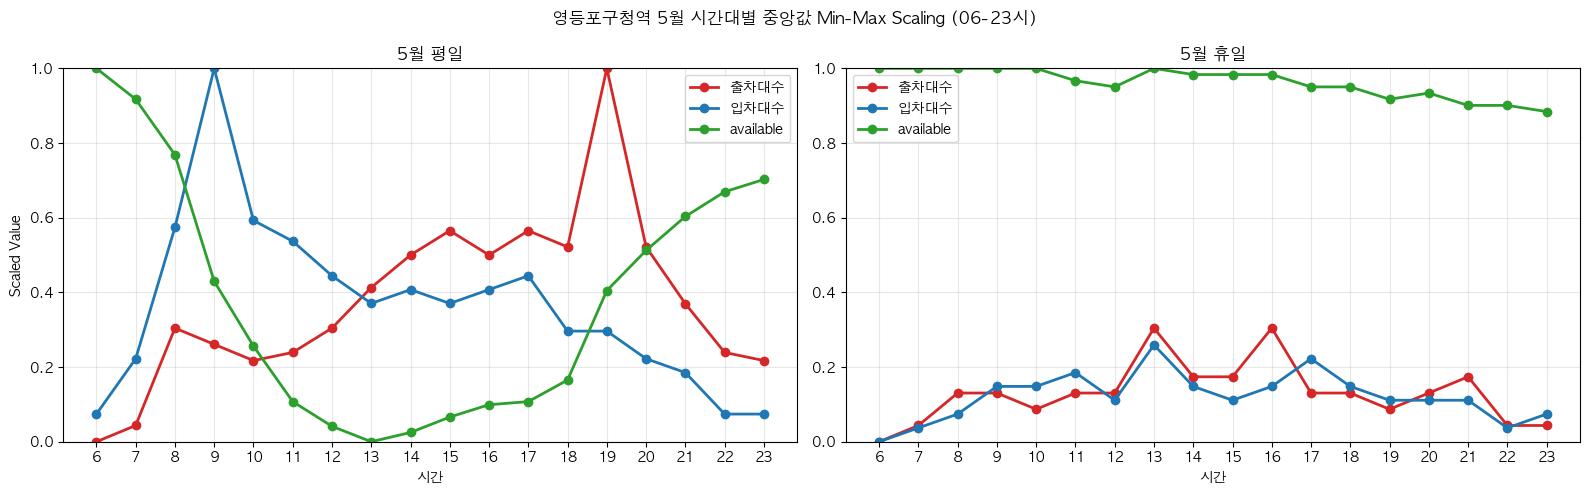

,day_type,hour,출차대수,입차대수,available
0,평일,6,0.000000,0.074074,1.000000
1,평일,7,0.043478,0.222222,0.917355
2,평일,8,0.304348,0.574074,0.768595
3,평일,9,0.260870,1.000000,0.429752
4,평일,10,0.217391,0.592593,0.256198
5,평일,11,0.239130,0.537037,0.107438
6,평일,12,0.304348,0.444444,0.041322
7,평일,13,0.413043,0.370370,0.000000
8,평일,14,0.500000,0.407407,0.024793
9,평일,15,0.565217,0.370370,0.066116


In [125]:
monthly_profile_5 = plot_monthly_profile(5)
monthly_profile_5